In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
%matplotlib inline

In [6]:
from google.colab import files

uploaded = files.upload()
# Get the uploaded file name
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name, encoding='latin1')
df.head()

Saving superstore_final_dataset.csv to superstore_final_dataset (4).csv


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [13]:
print("Shape of Dataset:", df.shape)
df.info()
df.describe()

# Check Missing Values
print(df.isnull().sum())

# Fill missing values if any
df.fillna("Unknown", inplace=True)

# Remove duplicates
print("Duplicates Before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicates After:", df.duplicated().sum())

# --- FIX: Convert date columns to datetime first ---
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='mixed')
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], format='mixed')

# Create Time Features
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month_name()
df['Month_No'] = df['Order_Date'].dt.month
df['Quarter'] = df['Order_Date'].dt.quarter
df['Weekday'] = df['Order_Date'].dt.day_name()

# Calculate Shipping days
df['Shipping_Days'] = (df['Ship_Date'] - df['Order_Date']).dt.days

# Check datatypes
df.dtypes

# Convert Sales to Numeric
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')

# Remove Negative Sales
df = df[df['Sales'] >= 0]

# Final Cleaned Dataset
df.head()
df.info()



Shape of Dataset: (9800, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9800 non-null   object 
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non

In [14]:
#KPI - Total Revenue
total_revenue = df['Sales'].sum()
print("Total Revenue:", total_revenue)
#KPI - Total Orders
total_orders = df['Order_ID'].nunique()
print("Total Orders:", total_orders)
#KPI - Average Order Value
average_order_value = total_revenue / total_orders
print("Average Order Value:", average_order_value)
#KPI - Total Customers
total_customers = df['Customer_ID'].nunique()
print("Total Customers:", total_customers)
#KPI - Average Shipping Days
average_shipping_days = df['Shipping_Days'].mean()
print("Average Shipping Days:", average_shipping_days)


Total Revenue: 2261536.7827000003
Total Orders: 4922
Average Order Value: 459.4751691791955
Total Customers: 793
Average Shipping Days: 9.22265306122449


In [15]:
#Profit Margin (Not Available)
if 'Profit' in df.columns:
    profit_margin = (df['Profit'].sum()/df['Sales'].sum())*100
    print(profit_margin)
else:
    print("Profit column not available in dataset.")
#Conversion Metrics (Not Available)
if 'Order_ID' in df.columns and 'Customer_ID' in df.columns:
    conversion_rate = (df['Order_ID'].nunique() / df['Customer_ID'].nunique()) * 100
    print(conversion_rate)
else:
  print("Conversion metrics not available")


Profit column not available in dataset.
620.6809583858764


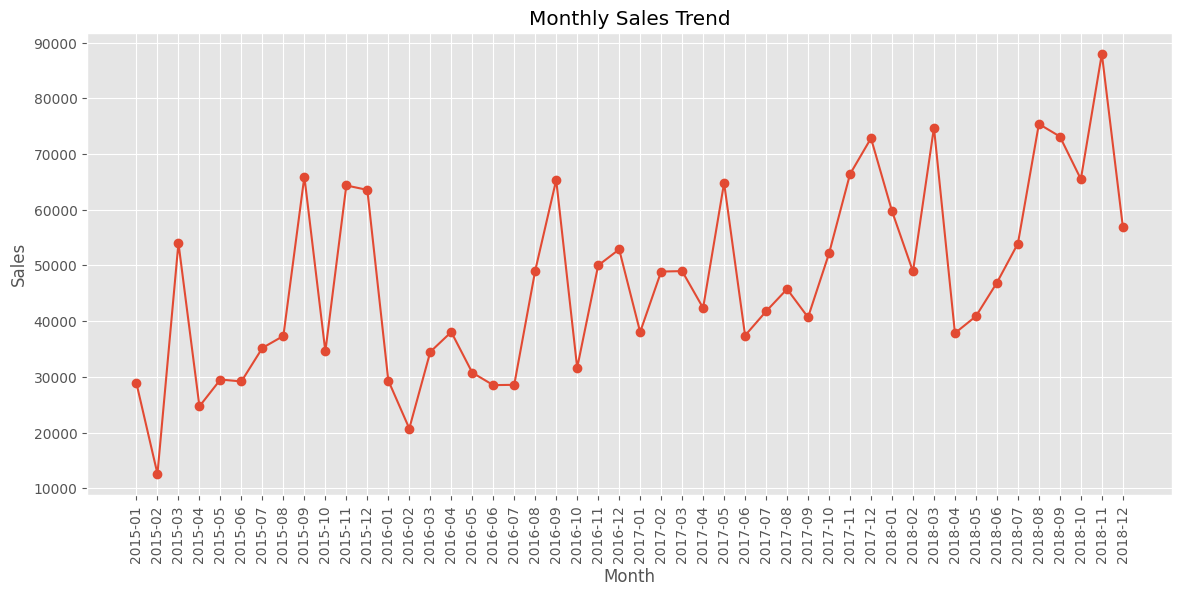

In [16]:
#Monthly Sales Trend
monthly_sales = df.groupby(df['Order_Date'].dt.to_period('M'))['Sales'].sum()
monthly_sales.index = monthly_sales.index.astype(str)
plt.figure(figsize=(14,6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.xticks(rotation=90)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()


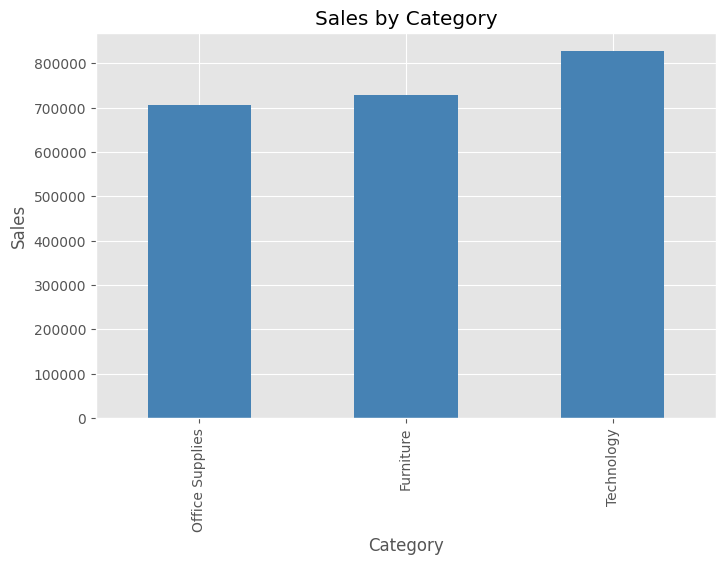

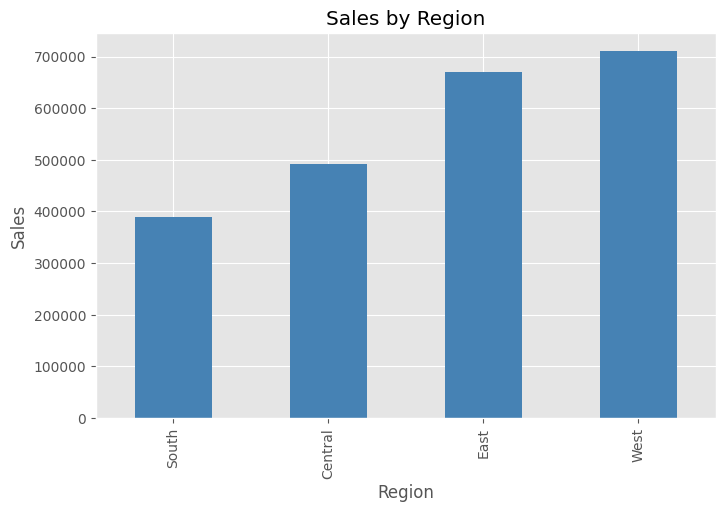

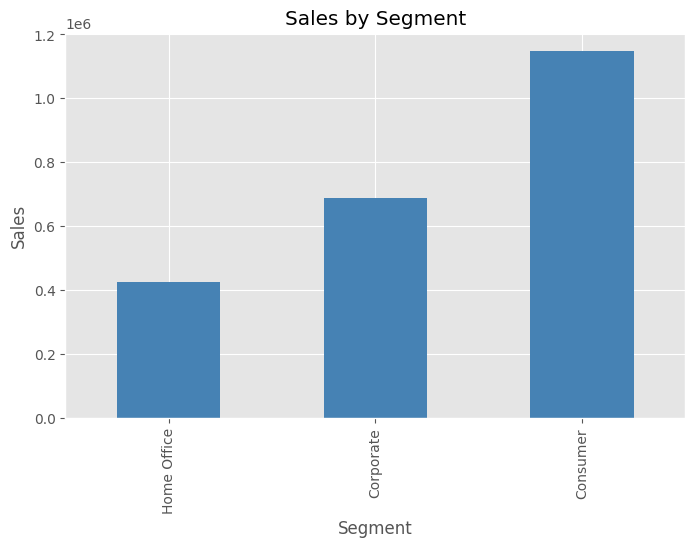

In [17]:
#Sales by Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values()
plt.figure(figsize=(8,5))
category_sales.plot(kind='bar', color='steelblue')
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()
#Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values()
plt.figure(figsize=(8,5))
region_sales.plot(kind='bar', color='steelblue')
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()
#Sales by Segment
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values()
plt.figure(figsize=(8,5))
segment_sales.plot(kind='bar', color='steelblue')
plt.title("Sales by Segment")
plt.ylabel("Sales")
plt.show()


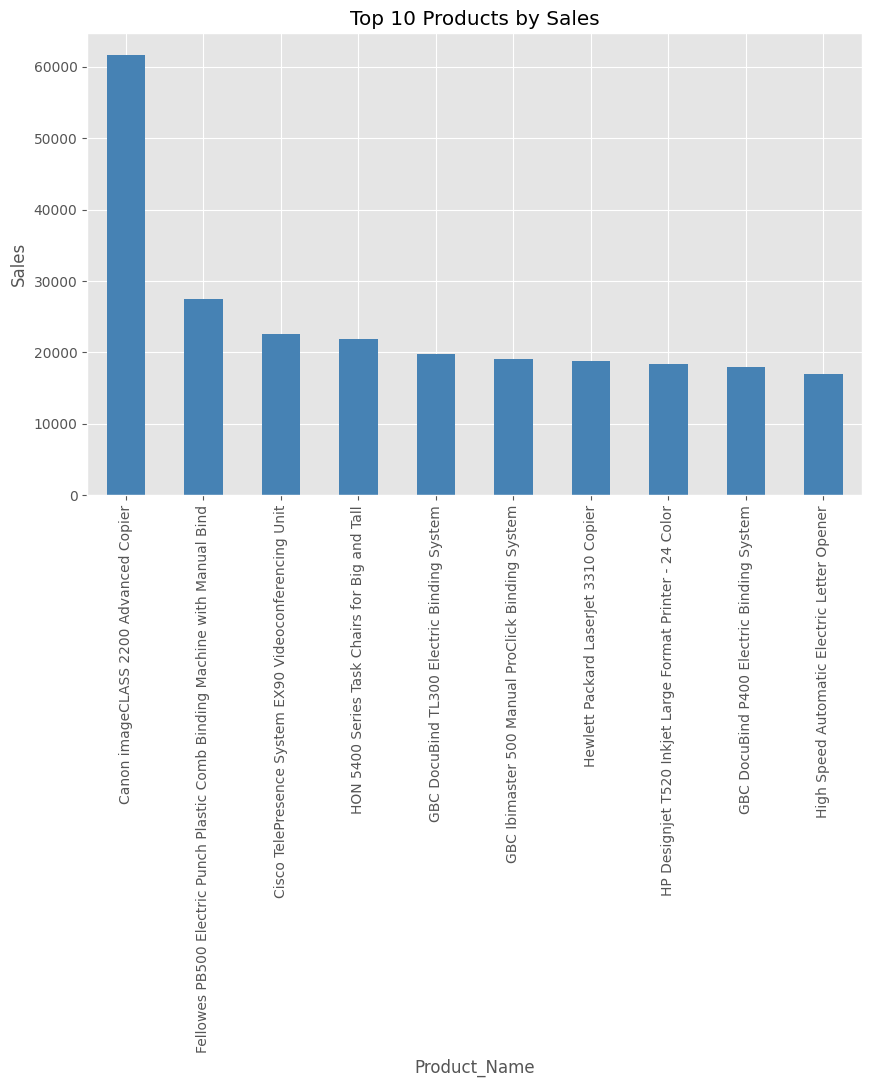

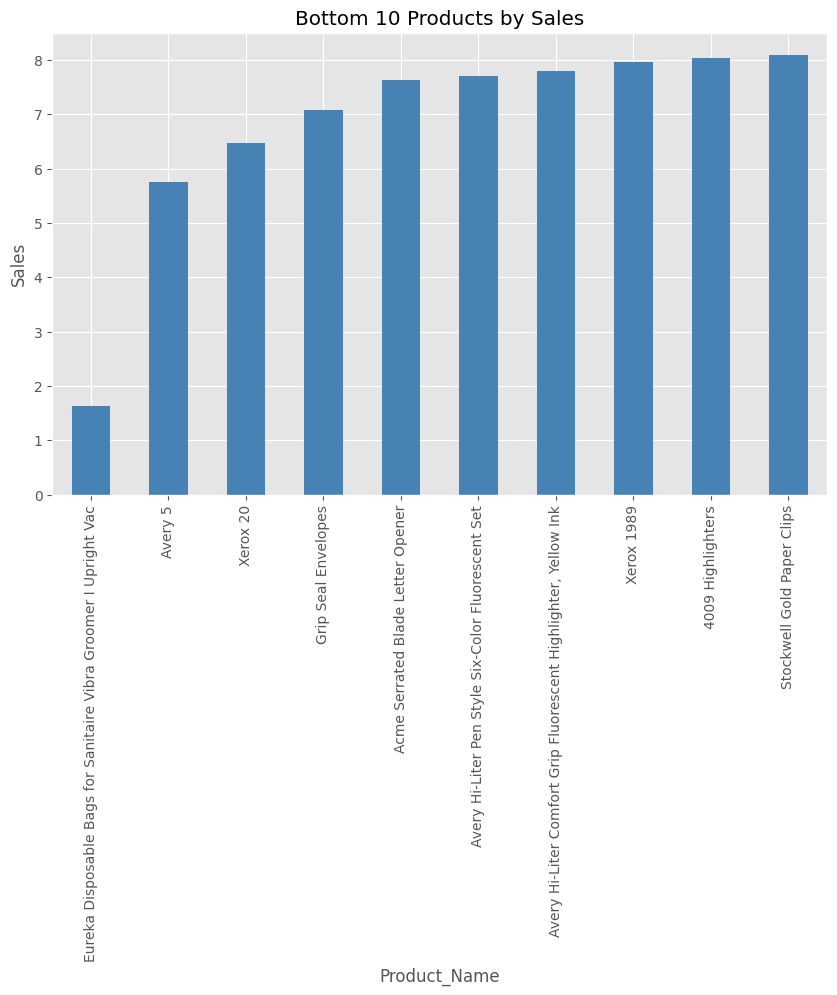

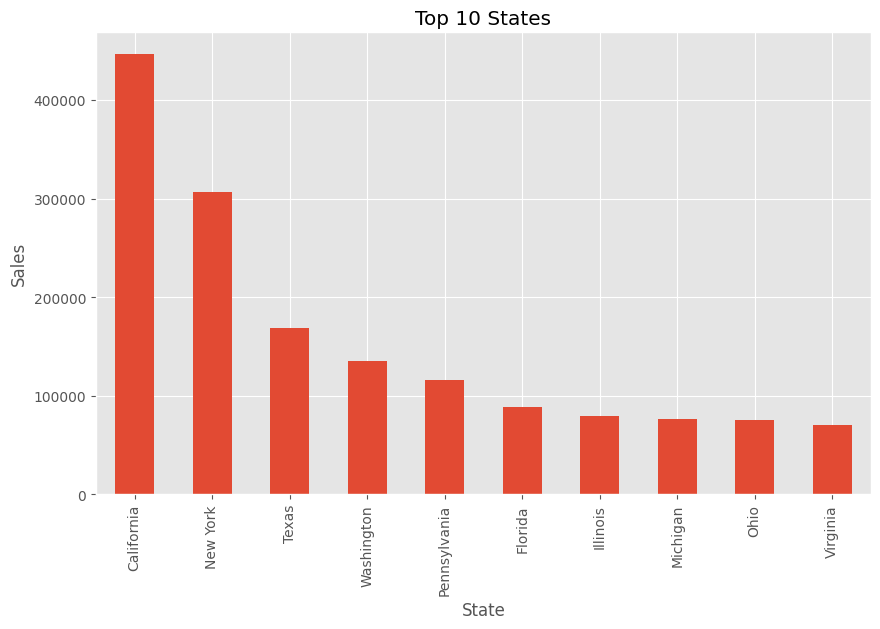

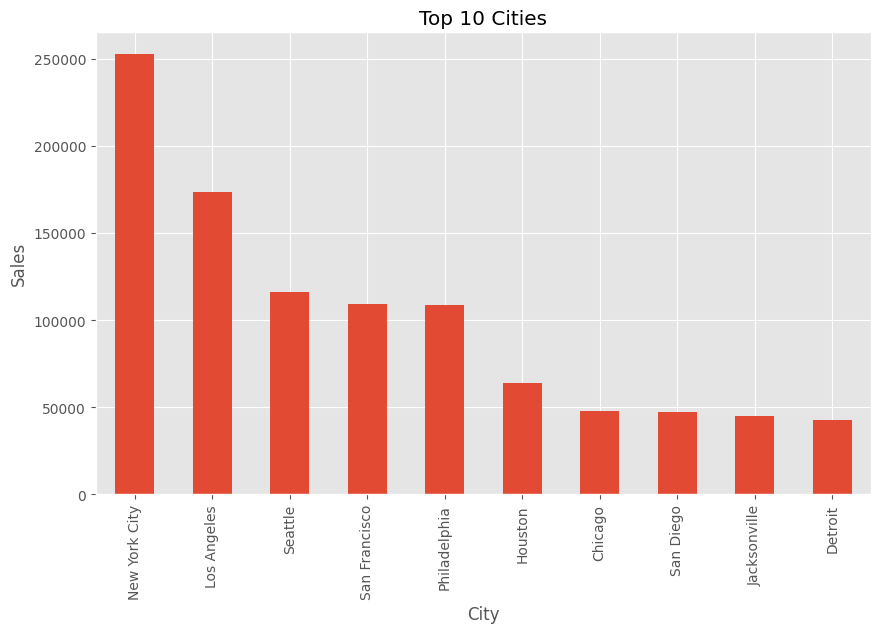

In [18]:
#Top 10 Products
top_products = df.groupby('Product_Name')['Sales'].sum().nlargest(10)
plt.figure(figsize=(10,6))
top_products.plot(kind='bar', color='steelblue')
plt.title("Top 10 Products by Sales")
plt.ylabel("Sales")
plt.show()

#Bottom 10 Producta
bottom_products = df.groupby('Product_Name')['Sales'].sum().nsmallest(10)
plt.figure(figsize=(10,6))
bottom_products.plot(kind='bar', color='steelblue')
plt.title("Bottom 10 Products by Sales")
plt.ylabel("Sales")
plt.show()

#Top States
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
state_sales.plot(kind='bar')
plt.title("Top 10 States")
plt.ylabel("Sales")
plt.show()

#Top Cities
city_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
city_sales.plot(kind='bar')
plt.title("Top 10 Cities")
plt.ylabel("Sales")
plt.show()



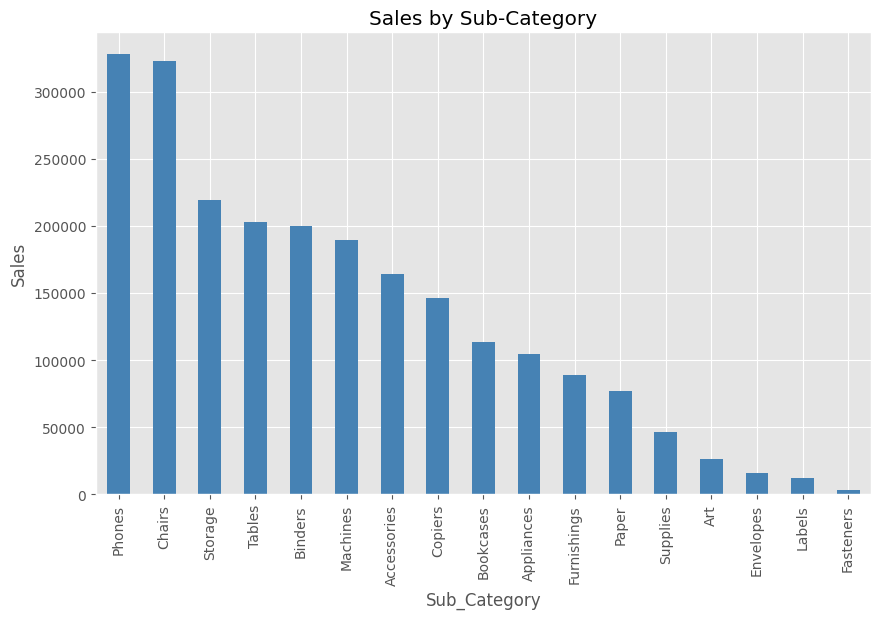

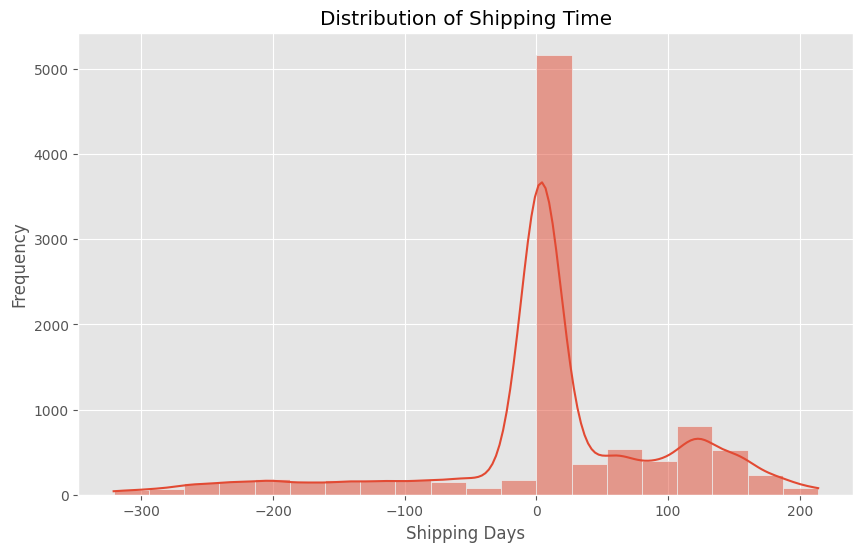

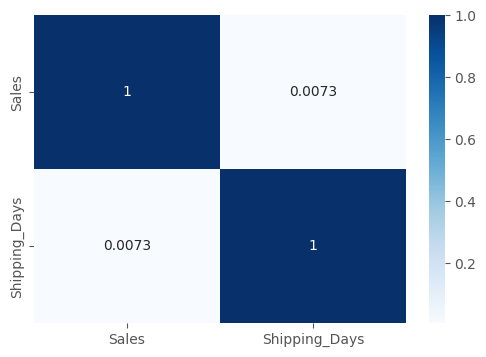

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
# Sub-Category Analysis
sub_category_sales = df.groupby('Sub_Category')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sub_category_sales.plot(kind='bar', color='steelblue')
plt.title("Sales by Sub-Category")
plt.ylabel("Sales")
plt.show()

# Shipping Time Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Shipping_Days'], bins=20, kde=True)
plt.title("Distribution of Shipping Time")
plt.xlabel("Shipping Days")
plt.ylabel("Frequency")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df[['Sales', 'Shipping_Days']].corr(),
            annot=True,
            cmap='Blues')
plt.show()

# Save & Download Clean Dataset
df.to_csv("Cleaned_Superstore.csv", index=False)
from google.colab import files
files.download("Cleaned_Superstore.csv")


In [21]:
#Business Insights
print("Business Insights")
print("----------------------------")
print("1. Identify the highest revenue category.")
print("2. Focus marketing on top-selling products.")
print("3. Improve sales in low-performing regions.")
print("4. Increase inventory before peak sales months.")
print("5. Improve shipping efficiency to reduce delivery time.")

#Tactical Improvements for Alfido Tech
recommendations = [
    "Increase marketing budget for top-performing products.",
    "Bundle low-selling products with popular products.",
    "Expand operations in high-revenue regions.",
    "Run seasonal promotional campaigns before peak months.",
    "Improve logistics to reduce shipping time and increase customer satisfaction."
]

for i, rec in enumerate(recommendations, start=1):
    print(f"{i}. {rec}")


Business Insights
----------------------------
1. Identify the highest revenue category.
2. Focus marketing on top-selling products.
3. Improve sales in low-performing regions.
4. Increase inventory before peak sales months.
5. Improve shipping efficiency to reduce delivery time.
1. Increase marketing budget for top-performing products.
2. Bundle low-selling products with popular products.
3. Expand operations in high-revenue regions.
4. Run seasonal promotional campaigns before peak months.
5. Improve logistics to reduce shipping time and increase customer satisfaction.
